# Fengshui — Artifact Evaluation (MICRO 2026, anonymous)

This repository is the artifact for the artifact evaluation (AE) of the paper. It reproduces the paper's
key results from a shipped precomputed Timeloop/Accelergy performance database, on a CPU in minutes — no
GPU and no EDA license.

**Key results reproduced**
- **Figure 8** — chiplet pool optimization (SA vs. SAEO+I-SAEO across four metrics).
- **Figure 9** — architectural paradigms: co-design vs. homogeneous ASIC / GPU / unconstrained.
- **Table 3** — per-technique ablation on the fixed 8-chiplet pool.
- **Figure 10** — system-cost breakdown and cost-model sensitivity across manufacturing assumptions.

Determinism (`FENGSHUI_DETERMINISTIC=1`) makes every optimizer recompute bit-reproducible.


## Setup

In [1]:
import os, sys, subprocess, glob
from IPython.display import Image, display
os.environ['FENGSHUI_DETERMINISTIC'] = '1'; os.environ.setdefault('FENGSHUI_GA_SEED', '0')

root = os.getcwd()
while root != '/' and not os.path.isdir(os.path.join(root, 'src', 'scripts')):
    root = os.path.dirname(root)
SCRIPTS = os.path.join(root, 'src', 'scripts'); os.chdir(SCRIPTS)
FIG_OUT = os.path.join(root, 'notebooks', '_figures'); os.makedirs(FIG_OUT, exist_ok=True)
os.environ['FENGSHUI_FIG_OUT'] = FIG_OUT; os.environ['FENGSHUI_SCRIPTS'] = SCRIPTS
DB_PATH = os.path.abspath(os.path.join(SCRIPTS, '..', 'unified_database.csv'))
DB_HEADER = ('net,layer_name,batch_size,sequence_length,mapper_idx,fused_layer_type,tp_degree,'
             'arch_target,glb_scale,pe_x_scale,pe_y_scale,dram_i,dram_o,latency,static_power,'
             'dynamic_energy,area,utilization,i_access,w_access,o_access')
DB_EXPECT_BYTES = 4903678840          # the shipped unified_database.csv
DB_MIN_BYTES    = 1_000_000_000       # anything smaller is a failed download / gunzip

def _check_db(path):
    """Existence alone is not enough: `gunzip -c a.gz > b` run from the wrong
    directory leaves a 0-byte b behind, which would look PRESENT here and fail
    much later in a confusing way.  Also require a plausible size + the header."""
    hint = ('             fetch/extract it with:   bash ../../tools/download_data.sh\n'
            '             (from the repo root:      bash tools/download_data.sh)\n'
            f'             expected file:           {path}')
    if not os.path.exists(path):
        return False, 'ABSENT\n' + hint
    size = os.path.getsize(path)
    if size < DB_MIN_BYTES:
        return False, (f'TRUNCATED/EMPTY  ({size:,} bytes, expected ~{DB_EXPECT_BYTES:,})\n'
                       '             delete the bad file and retry -- a 0-byte file is the\n'
                       '             usual sign of a gunzip run from the wrong directory.\n' + hint)
    try:
        with open(path, 'r', errors='replace') as _fh:
            first = _fh.readline().strip()
    except OSError as e:
        return False, f'UNREADABLE  ({e})\n' + hint
    if first != DB_HEADER:
        return False, ('UNRECOGNIZED HEADER -- this is not the Fengshui database\n'
                       f'             got     : {first[:90]}\n'
                       f'             expected: {DB_HEADER[:90]}\n' + hint)
    return True, f'PRESENT  ({size:,} bytes, header OK)  -> reproduce from the optimizer'

HAVE_DB, DB_STATUS = _check_db(DB_PATH)

_NOISE = ('gym has been','please upgrade','migration guide','users of this version',
          'does not support numpy','Matplotlib is building')
def run(cmd):
    print('$', ' '.join(str(c) for c in cmd))
    r = subprocess.run([str(c) for c in cmd], capture_output=True, text=True)
    for l in (r.stdout + r.stderr).splitlines():
        if not any(n in l for n in _NOISE): print(l)
    return r
import numpy as np, pandas as pd
def gm(x): x=[v for v in x if v>0]; return float(np.exp(np.mean(np.log(x)))) if x else float('nan')

def show_fig(*candidates, label=''):
    """Display the first candidate path that exists; skip gracefully otherwise."""
    for p in candidates:
        if p and os.path.exists(p):
            if label: print(f'[figure] {label}: {p}')
            display(Image(p)); return p
    print('[figure] not found, skipped:', ', '.join(str(p) for p in candidates))
    return None

print('scripts  :', SCRIPTS)
print('database :', DB_STATUS)

scripts  : /fengshui/src/scripts
database : PRESENT  (4,903,678,840 bytes, header OK)  -> reproduce from the optimizer


## Figure 8 — chiplet pool optimization (SA vs. SAEO+I-SAEO)

The chiplet pool is the output of the SA→SAEO→I-SAEO search. Regenerate Figure 8 (geomean across
workloads, four metrics, normalized to N=1), then optionally re-run the search to re-create the pool and
diff it against the shipped one. The pool built here is used by Figure 9 and Table 3 and supplies the
per-paradigm summaries consumed by Figure 10.


$ /usr/local/bin/python3.13 generate_paper_fig6_chain.py


[Energy] SA:    /fengshui/src/scripts/../archgym_results/v7_energy_sa/incremental_chiplet_sweep_energy_20260615_230904.csv
[Energy] Chain: /fengshui/src/scripts/../archgym_results/ae_energy_chain/saeo_isaeo_chain_energy_20260715_051806.csv
[Energy $\times$ Cost] SA:    /fengshui/src/scripts/../archgym_results/v7_energy_cost_sa/incremental_chiplet_sweep_energy_20260616_160357.csv
[Energy $\times$ Cost] Chain: /fengshui/src/scripts/../archgym_results/ae_energy_cost_chain/saeo_isaeo_chain_energy_20260715_075010.csv
[EDP] SA:    /fengshui/src/scripts/../archgym_results/v7_edp_sa/incremental_chiplet_sweep_edp_20260616_160421.csv
[EDP] Chain: /fengshui/src/scripts/../archgym_results/ae_edp_chain/saeo_isaeo_chain_edp_20260715_101936.csv
[EDP $\times$ Cost] SA:    /fengshui/src/scripts/../archgym_results/v7_edp_cost_sa/incremental_chiplet_sweep_edp_20260616_160422.csv
[EDP $\times$ Cost] Chain: /fengshui/src/scripts/../archgym_results/ae_edp_cost_chain/saeo_isaeo_chain_edp_20260715_125001.csv


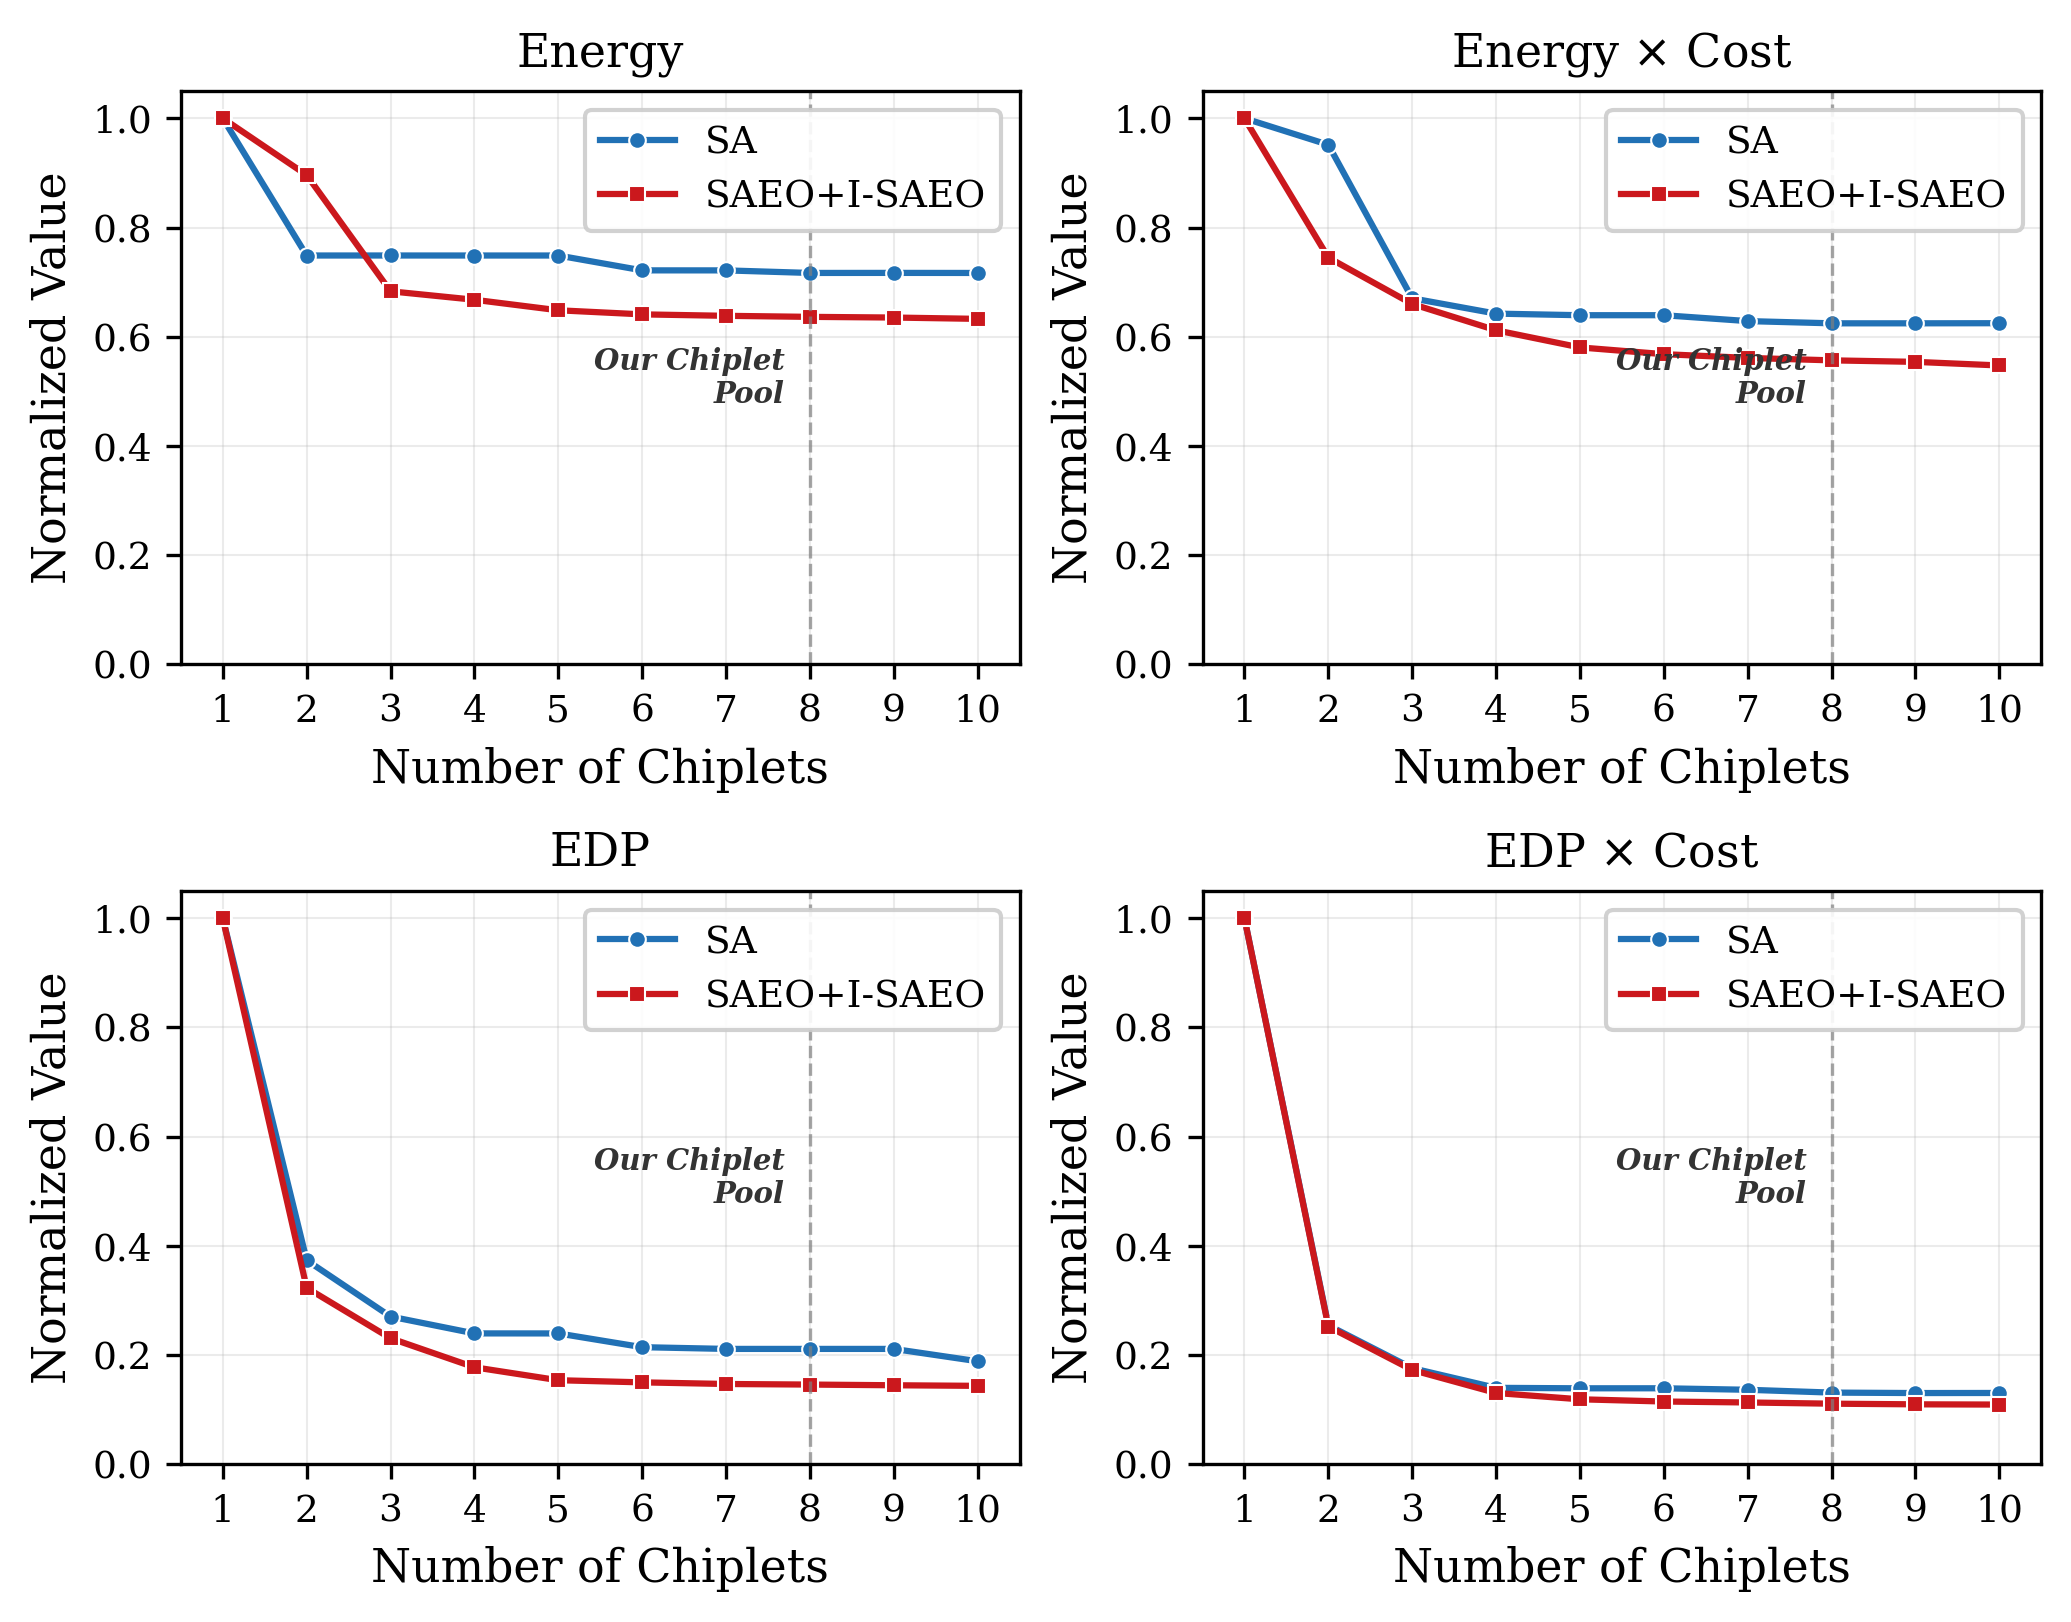

In [2]:
# regenerate Figure 8 (SA baseline vs. SAEO+I-SAEO chain)
run([sys.executable, 'generate_paper_fig6_chain.py'])
display(Image(os.path.join(FIG_OUT, 'num_chiplet_sweep.png')))

### What is bit-reproducible, and what may vary across machines

- **Inner GA remap (Figure 9 and Table 3): bit-reproducible.** `FENGSHUI_DETERMINISTIC=1`
  reseeds the per-network GA from a stable hash of the network name, so the recomputes below are
  independent of worker count and machine. Figure 10 is deterministic cost-model post-processing.
- **Outer pool search (the cell below): may vary across machines.** The SAEO / I-SAEO surrogate is a
  `RandomForestRegressor(..., n_jobs=-1)` (`src/scripts/run_archgym_chiplet.py:1187` and `:1479`), so its
  thread count equals the machine core count, and scikit-learn's random-forest `predict` is not
  guaranteed bitwise identical across thread counts. The search is seeded, but a re-search on a
  different machine may therefore land on a slightly different pool. The shipped pools in
  `src/archgym_results/ae_*_chain/` are the canonical inputs to every downstream result; the diff below
  is a consistency check, not a bit-exactness guarantee.


In [3]:
# OPT-IN (~1-2 h per metric): re-create all four pools from scratch, then diff vs. the shipped pools.
# Enable with an environment variable -- no need to edit this cell:
#     FENGSHUI_RUN_POOL_SEARCH=1 jupyter nbconvert --execute notebooks/reproduce_all.ipynb
# or, in a running notebook:  os.environ['FENGSHUI_RUN_POOL_SEARCH'] = '1'  and re-run this cell.
# Needs the database + `gym`.  See the note above on cross-machine variability.
RUN_POOL_SEARCH = os.environ.get('FENGSHUI_RUN_POOL_SEARCH') == '1'

POOLS = [  # (objective, extra flags, shipped dir, output dir)
    ('energy', [],               'ae_energy_chain',      'repro_energy_chain'),
    ('energy', ['--cost-aware'], 'ae_energy_cost_chain', 'repro_energy_cost_chain'),
    ('edp',    [],               'ae_edp_chain',         'repro_edp_chain'),
    ('edp',    ['--cost-aware'], 'ae_edp_cost_chain',    'repro_edp_cost_chain'),
]
for obj, extra, _, out in POOLS:
    print(' '.join([sys.executable, 'run_saeo_isaeo_chain.py', '--objective', obj, *extra,
                    '--database', '../unified_database.csv', '--output-dir', f'../archgym_results/{out}']))

if RUN_POOL_SEARCH and HAVE_DB:
    print('\nFENGSHUI_RUN_POOL_SEARCH=1 -- running the four searches now (hours).')
    for obj, extra, _, out in POOLS:
        run([sys.executable, 'run_saeo_isaeo_chain.py', '--objective', obj, *extra,
             '--database', '../unified_database.csv', '--output-dir', f'../archgym_results/{out}'])
elif RUN_POOL_SEARCH:
    print('\nFENGSHUI_RUN_POOL_SEARCH=1 but the database is missing/unusable -- skipped.')
    print('  ' + DB_STATUS.replace(chr(10), chr(10) + '  '))
else:
    print('\n[skipped] pool search is opt-in. Set FENGSHUI_RUN_POOL_SEARCH=1 to actually run it')
    print('          (the commands above are exactly what would be executed).')


/usr/local/bin/python3.13 run_saeo_isaeo_chain.py --objective energy --database ../unified_database.csv --output-dir ../archgym_results/repro_energy_chain
/usr/local/bin/python3.13 run_saeo_isaeo_chain.py --objective energy --cost-aware --database ../unified_database.csv --output-dir ../archgym_results/repro_energy_cost_chain
/usr/local/bin/python3.13 run_saeo_isaeo_chain.py --objective edp --database ../unified_database.csv --output-dir ../archgym_results/repro_edp_chain
/usr/local/bin/python3.13 run_saeo_isaeo_chain.py --objective edp --cost-aware --database ../unified_database.csv --output-dir ../archgym_results/repro_edp_cost_chain

[skipped] pool search is opt-in. Set FENGSHUI_RUN_POOL_SEARCH=1 to actually run it
          (the commands above are exactly what would be executed).


In [4]:
# after the four searches finish, check each recomputed pool matches the shipped one
import json
def _n8(d):
    j = json.load(open(sorted(glob.glob(f'../archgym_results/{d}/chain_summary_*.json'))[-1]))
    return set(map(str, j['n8']['best_chiplets']))
for _, _, shipped, out in POOLS:
    try:
        print(f'{out:24} identical to shipped: {_n8(out) == _n8(shipped)}')
    except (IndexError, FileNotFoundError):
        print(f'{out:24} not computed yet -- set FENGSHUI_RUN_POOL_SEARCH=1 (env var) and re-run '
              'the cell above (~1-2 h per metric)')


repro_energy_chain       not computed yet -- set FENGSHUI_RUN_POOL_SEARCH=1 (env var) and re-run the cell above (~1-2 h per metric)
repro_energy_cost_chain  not computed yet -- set FENGSHUI_RUN_POOL_SEARCH=1 (env var) and re-run the cell above (~1-2 h per metric)
repro_edp_chain          not computed yet -- set FENGSHUI_RUN_POOL_SEARCH=1 (env var) and re-run the cell above (~1-2 h per metric)
repro_edp_cost_chain     not computed yet -- set FENGSHUI_RUN_POOL_SEARCH=1 (env var) and re-run the cell above (~1-2 h per metric)


## Figure 9 — architectural paradigms

Energy, energy×\$, EDP, and EDP×\$ of the co-designed chiplet pool vs. homogeneous ASIC, GPU, and the
unconstrained ideal, normalized to the homogeneous ASIC. Regenerate the figure, then optionally re-run the
co-design optimizer live.

$ /usr/local/bin/python3.13 generate_paper_fig10.py --chain-version ae


=== Fig 11 (A2 iso-throughput cost) | chain=ae | competing=competing_ae_raw.csv ===
Saved /fengshui/notebooks/_figures/combined_comparison_norm_two_row_new.pdf

=== RECOMPUTED constants/constants.tex (A2 iso; homo baseline = Gemini-style) ===
  \poolEnergyRed        = 48.5
  \poolECRed            = 88.1
  \poolEDPRed           = 93.0
  \poolEDPCRed          = 97.8
  \gpuVsHomoEnergy      = 8.3
  \gpuVsHomoEC          = 45.9
  \gpuVsHomoEDP         = 1.44
  \gpuVsHomoEDPC        = 19.7
  \gpuVsHomoEnergyNoRep = 6.7
  \gpuVsHomoEDPNoRep    = 0.86
  \decodeEnergyRed      = 71
  \decodeEDPRed         = 99
  \prefillEnergyRed     = 25
  \cnnEnergyRed         = 22
  \poolVsUnconGap       = 4.8   (per-metric E/EC/EDP/EDPC: 0.6, 4.8, 1.6, 1.5)


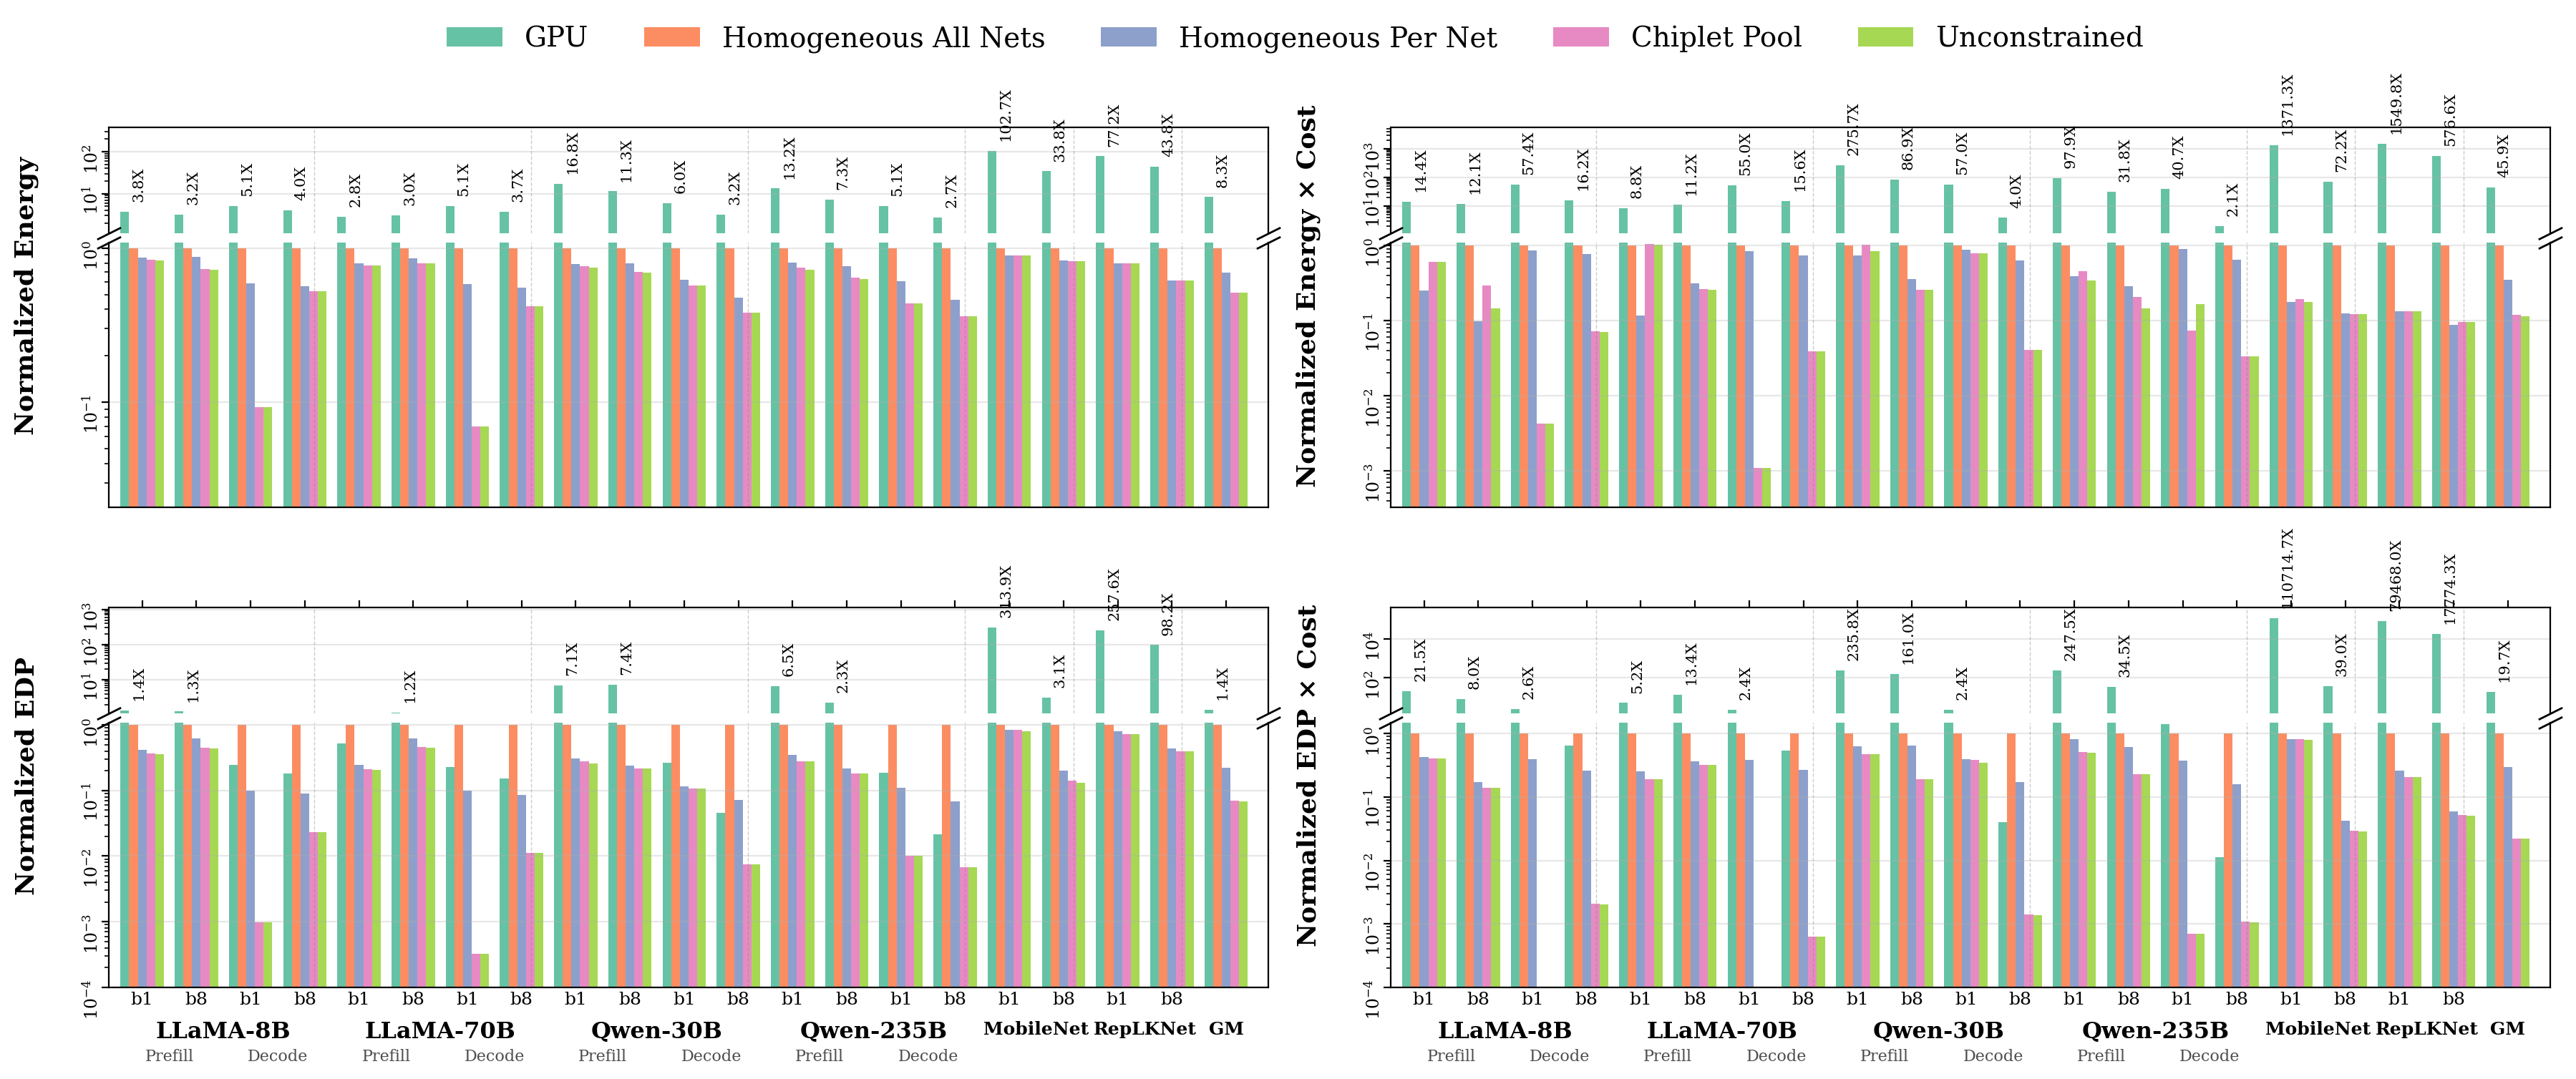

In [5]:
# regenerate Figure 9
run([sys.executable, 'generate_paper_fig10.py', '--chain-version', 'ae'])
display(Image(os.path.join(FIG_OUT, 'combined_comparison_norm_two_row_new.png')))

In [ ]:
# re-run the co-design optimizer live (needs the database)
if HAVE_DB:
    run([sys.executable, 'arch_impl/competing_baselines.py', '--chain-version', 'ae',
         '--frameworks', 'Fengshui (Full)', '--workers', '8', '--out-prefix', 'arch_impl/competing_repro'])
    rep = pd.read_csv('arch_impl/competing_repro_raw.csv')
    ff = rep[(rep.framework=='Fengshui (Full)') & (rep.objective=='energy') & (rep.cost_aware.astype(str)=='False')]
    print(f'\n  live optimizer re-run  (energy geomean) = {gm(ff["value"].tolist()):.6g}')
else:
    print('DB absent — run  bash tools/download_data.sh  then re-run this cell.')

## Table 3 — per-technique ablation

Per-technique ablation on the fixed 8-chiplet pool (geomean over all workloads, normalized to full
Fengshui). Regenerate the heatmap from the shipped ablation results, then optionally recompute from the
database.

$ /usr/local/bin/python3.13 arch_impl/generate_ablation_heatmap.py --summary arch_impl/ablation_factorial_ae_summary.csv --no-overleaf


[sanity] CHECKED: 64 combo x metric cells present and finite; no combo beats Full by >1%; 16 single-off values match ablation_v2 (max rel diff 0.00e+00, tol 3%).
[sanity] NOT CHECKED: the all-on row (1.0 by construction), and absolute magnitudes against the database.
[figure] -> /fengshui/notebooks/_figures/ablation_heatmap.pdf
[constants] -> /fengshui/src/scripts/arch_impl/ablation_constants.tex

Interaction digest (observed all-off vs product of singles):
  Energy         observed  1.25x  product-of-singles  1.23x  ratio 1.01
  EDP            observed  2.00x  product-of-singles  2.43x  ratio 0.82
  Energy x Cost  observed  1.52x  product-of-singles  1.59x  ratio 0.96
  EDP x Cost     observed  1.39x  product-of-singles  1.34x  ratio 1.03
[figure] Table 3 heatmap (SHIPPED ablation_factorial_ae_summary.csv): /fengshui/notebooks/_figures/ablation_heatmap.png


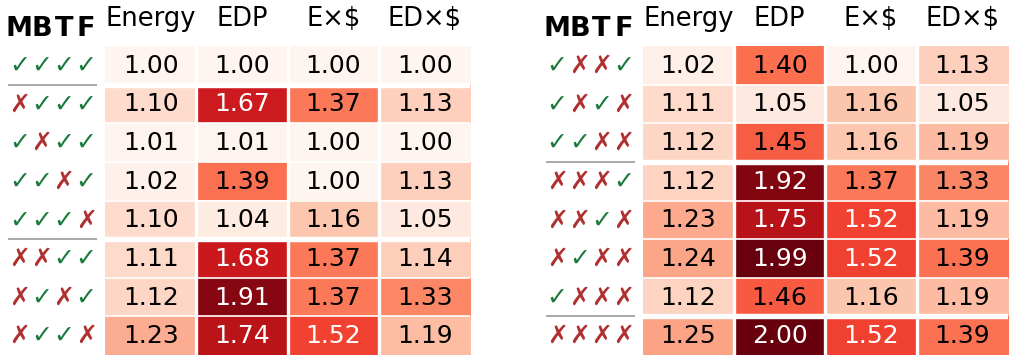

'/fengshui/notebooks/_figures/ablation_heatmap.png'

In [7]:
# regenerate the ablation heatmap from the SHIPPED ablation results (Table 3 numbers)
run([sys.executable, 'arch_impl/generate_ablation_heatmap.py',
     '--summary', 'arch_impl/ablation_factorial_ae_summary.csv', '--no-overleaf'])
show_fig(os.path.join(FIG_OUT, 'ablation_heatmap.png'),
         'arch_impl/images/ablation_heatmap.png',
         label='Table 3 heatmap (SHIPPED ablation_factorial_ae_summary.csv)')


In [ ]:
# recompute the ablation from the database (needs DB, ~10-20 min)
if HAVE_DB:
    run([sys.executable, 'arch_impl/ablation_factorial.py', '--chain-version', 'ae',
         '--workers', '8', '--out-prefix', 'arch_impl/ablation_repro'])
    run([sys.executable, 'arch_impl/generate_ablation_heatmap.py',
         '--summary', 'arch_impl/ablation_repro_summary.csv', '--no-overleaf'])

    show_fig(os.path.join(FIG_OUT, 'ablation_heatmap.png'),
             'arch_impl/images/ablation_heatmap.png',
             label='Table 3 heatmap (RECOMPUTED ablation_repro_summary.csv)')
else:
    print('DB absent/unusable -- ablation recompute skipped.')
    print(DB_STATUS)


## Figure 10 — system cost under manufacturing-volume and cost-model sweeps

Figure 10 reports the geometric mean over all evaluated networks for a 200-network fleet.
Panel (a) breaks per-unit cost into die, packaging, NRE, and operational (lifetime-energy) cost
across paradigms; each paradigm has sub-bars for manufacturing volumes of 1/2/3 million units.
Panel (b) sweeps NRE, volume, packaging, interposer, wafer, die-defect density, and electricity
price one at a time. Bar ends show absolute parameter values with units; gray marks the default
model and red marks break-even.

The following cell regenerates both panels from the shipped per-paradigm area/energy summaries,
prints all numerical endpoints, and gates the paper claim that the pool remains **3.6–30.2×**
cheaper than fully bespoke (unconstrained) heterogeneity throughout the sweeps. No performance
database is needed for this post-processing step.


In [ ]:
# Regenerate Figure 10 and enforce its numerical claim.
import re
FIG10_DIR = os.path.join(root, "src", "cost_model", "cost_model")
FIG10_PNG = os.path.join(FIG_OUT, "nre_cost_combined.png")
FIG10_PDF = os.path.join(FIG_OUT, "nre_cost_combined.pdf")

sweep = run([sys.executable, os.path.join(FIG10_DIR, "generate_cost_sweep.py")])
assert sweep.returncode == 0, "Figure 10 sensitivity sweep failed"
factors = [float(x) for x in re.findall(r"->\s*([0-9.]+)x", sweep.stdout)]
lo, hi = min(factors), max(factors)
assert round(lo, 1) == 3.6 and round(hi, 1) == 30.2, (lo, hi)
print(f"[gate] sensitivity range = {lo:.2f}–{hi:.2f}x (paper: 3.6–30.2x)")

for out in (FIG10_PNG, FIG10_PDF):
    result = run([sys.executable, os.path.join(FIG10_DIR, "generate_fig10_compact.py"),
                  "--save", out])
    assert result.returncode == 0, f"Figure 10 generation failed: {out}"
display(Image(FIG10_PNG))


## Database provenance (Timeloop) — not automated

The shipped `src/unified_database.csv` was produced by a Timeloop/Accelergy mapper sweep that takes
roughly a month of CPU time; it is distributed precomputed and every result above is derived from it.

**What is automated:** `docker/Dockerfile.timeloop` builds the Timeloop/Accelergy toolchain plus the
sweep and parsing code (`src/timeloop_experiments/`, `src/timeloop/`), so the generating pipeline is
inspectable and buildable:

```bash
docker build -f docker/Dockerfile.timeloop -t fengshui-timeloop .
```

**What is not automated:** this artifact ships **no** tiny-sweep driver and **no** stats-to-database
row-matching script, so re-deriving database rows from a fresh Timeloop run is a manual exercise —
run one of the sweep drivers in `src/timeloop_experiments/` for a single layer/config inside that
image, then compare the parsed stats against the corresponding row of `src/unified_database.csv`.
Reproducing the paper's results does **not** require this step.